# ADD RANDOMNESS TO THE PARAMETER BOUNDS WHEN DOING REPEATED SIMULATIONS

In [34]:
import time
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import taichi as ti
ti.init(arch=ti.gpu, default_fp=ti.f32)

[Taichi] Starting on arch=vulkan


Getting the data to compare to.

In [35]:
data = np.genfromtxt(input("File path to data:"), delimiter=",", skip_header=True)
# data = np.genfromtxt("../../tracking/test.csv", delimiter=",", skip_header=True)
num_time_datapoints = data.shape[0]

v1_range = (0, 0.005)
v2_range = (0, 0.0005)
v3_range = (0, 0.05)

Setting up the number of simulations happening at the same time, and for how long they should run.

In [36]:
num_sims = (150, 150, 150)
# in seconds, running the simulation for as long as the data goes
sim_time = data[-1, 0]

In [37]:
sims = ti.Vector.field(2, ti.float32, shape=num_sims)
costs = ti.field(ti.f32, shape=num_sims)

Helper Taichi functions

In [38]:
@ti.pyfunc
def map_range(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
    return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out


# a normal python version
# def map_range_py(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
#     return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out

Setting up initial conditions of the pendulums.

In [39]:
initial_theta = float(input("Initial angle of the pendulum"))
initial_omega = float(input("Initial angular velocity of the pendulum"))

@ti.kernel
def setup(v1_range: ti.math.vec2, v2_range: ti.math.vec2, v3_range: ti.math.vec2):
    for i, j, k in sims:
        theta_0 = initial_theta
        theta_d_0 = initial_omega

        sims[i, j, k] = ti.Vector([theta_0, theta_d_0])
        costs[i, j, k] = 0

Defining the function $f$ in $y' = f(y)$

In [40]:
# taichi versions

@ti.pyfunc
def get_angular_acceleration(y: ti.math.vec2, I: float, rcm: float, m: float, g: float, r_inner: float, muv: float, muq: float, muc: float) -> float:
    return -(y[1]*muv + y[1]*muq*abs(y[1]) + r_inner*muc*ti.tanh(100*y[1])*ti.abs(m*(y[1]**2*rcm + g*ti.cos(y[0]))) + rcm*g*m*ti.sin(y[0]))/I


@ti.pyfunc
def f(y: ti.math.vec2, I: float, rcm: float, m: float, g: float, r_inner: float, muv: float, muq: float, muc: float) -> ti.math.vec2:
    return ti.Vector([
        y[1],
        get_angular_acceleration(y, I, rcm, m, g, r_inner, muv, muq, muc)
    ])


# python versions

# def get_angular_acceleration_py(y, I, rcm, m, g):
#     return -rcm*g*m*np.sin(y[0])/I


# def f_py(y, I, rcm, m, g):
#     return np.array([
#         y[1],
#         get_angular_acceleration_py(y, I, rcm, m, g)
#     ])

A simulation step.

In [41]:
h = 0.01  # simulation time increment


@ti.kernel
def update(step: float, v1_range: ti.math.vec2, v2_range: ti.math.vec2, v3_range: ti.math.vec2):

    # setting parameters kept constant, ones we are pretty sure of
    m = 200e-3
    g = 9.81
    rcm = 10e-2
    I = 1/3 * (2*rcm)**2
    r_inner = 8e-3

    for i, j, k in sims:
        # setting parameters which change for each simulation
        muv = map_range(i, 0, num_sims[0], v1_range[0], v1_range[1])
        muq = map_range(i, 0, num_sims[0], v2_range[0], v2_range[1])
        muc = map_range(i, 0, num_sims[0], v3_range[0], v3_range[1])

        oldValue = sims[i, j, k]
        k1 = step * f(oldValue, I, rcm, m, g, r_inner, muv, muq, muc)
        k2 = step * f(oldValue + k1/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k3 = step * f(oldValue + k2/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k4 = step * f(oldValue + k3, I, rcm, m, g, r_inner, muv, muq, muc)

        newValue = oldValue + k1/6 + k2/3 + k3/3 + k4/6
        sims[i, j, k] = newValue

Determining the $\chi^2$ contribution for this data point. This kernel runs when a data point lies between this simulation step and the next (in time). A RK4 step is then performed to get the simulation to the time at which the data point was recorded. Finally, the position at the end of the pivot is calculated for the data point and the simulated point, and their squared distances are divided by the data uncertainty and added to the running $\chi^2$ value. This is all done for each simulation simultaneously.

$\chi^2 = \sum^{N}_{i=1} \left[ \frac{y_i - f(x_i)}{\alpha_i}  \right]^2$

In [42]:
@ti.func
def get_chi_squared_term(prediction: ti.math.vec2, data: ti.math.vec2, data_error: ti.math.vec2) -> float:
    term_sqrt = (data - prediction) / data_error
    return ti.math.dot(term_sqrt, term_sqrt)


@ti.kernel
def add_cost(time_offset: float, data: ti.math.vec2, data_error: ti.math.vec2, v1_range: ti.math.vec2, v2_range: ti.math.vec2, v3_range: ti.math.vec2):
    # ! all of this needs to be identical to the values in update, except for time_offset instead of h

    # setting parameters kept constant, ones we are pretty sure of
    m = 200e-3
    g = 9.81
    rcm = 10e-2
    I = 1/3 * (2*rcm)**2
    r_inner = 8e-3

    for i, j, k in sims:
        # setting parameters which change for each simulation
        muv = map_range(i, 0, num_sims[0], v1_range[0], v1_range[1])
        muq = map_range(i, 0, num_sims[0], v2_range[0], v2_range[1])
        muc = map_range(i, 0, num_sims[0], v3_range[0], v3_range[1])

        oldValue = sims[i, j, k]
        k1 = time_offset * f(oldValue, I, rcm, m, g, r_inner, muv, muq, muc)
        k2 = time_offset * f(oldValue + k1/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k3 = time_offset * f(oldValue + k2/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k4 = time_offset * f(oldValue + k3, I, rcm, m, g, r_inner, muv, muq, muc)

        prediction = oldValue + k1/6 + k2/3 + k3/3 + k4/6

        # getting simulated position
        theta = prediction[0]
        x = 2*rcm*ti.math.sin(theta)
        y = -2*rcm*ti.math.cos(theta)

        thisCost = get_chi_squared_term(ti.Vector([x, y]), data, data_error)
        costs[i, j, k] += thisCost

Visualizing the result.

In [43]:
pixels = ti.Vector.field(3, ti.f32, shape=(num_sims[0], num_sims[1]))


@ti.func
def colormap(val: float) -> ti.math.vec3:
    val = 1-val
    x = ti.max(0.0, ti.min(1.0, val))

    # A simplified Magma approximation
    r = 1.0 - ti.pow(1.0 - x, 3.0)
    g = ti.pow(x, 3.0) + 0.2 * ti.sin(3.14 * x)
    b = 0.2 + 0.6 * ti.pow(x, 5.0)

    return ti.Vector([ti.math.clamp(r, 0, 1),
                      ti.math.clamp(g, 0, 1),
                      ti.math.clamp(b, 0, 1)])


@ti.kernel
def draw(num_costs_calculated: int):
    for i, j in pixels:
        # pixels[i, j] = ti.Vector([sims[i, j][0], sims[i, j][1]/10 + 0.5, 0])
        costs_remapped = 0.14*ti.math.log(costs[i, j, ti.cast(num_sims[2]/2, ti.int32)]/num_costs_calculated + 1)
        pixels[i, j] = colormap(costs_remapped)

Running the simulation loop.

In [44]:
# at the end of this function, the costs buffer is updated
def get_costs(visualize, v1_range, v2_range, v3_range):
    if (visualize):
        window = ti.ui.Window("Visualization", (800, 800))
        canvas = window.get_canvas()

    t = 0
    index_in_data = 0

    setup(v1_range, v2_range, v3_range)

    time_steps = np.random.poisson(10, int(sim_time/h)) / 1000

    for time_step in time_steps:
        if visualize and not window.running:
            break

        this_data_entry = data[index_in_data, :]
        next_cost_time = this_data_entry[0]

        # by next frame we will have jumped over the next data point, so now is the time to calculate the costs
        if (t <= next_cost_time and next_cost_time < t + time_step):
            add_cost(
                next_cost_time - t,
                ti.Vector([this_data_entry[1], this_data_entry[2]]),
                ti.Vector([this_data_entry[3], this_data_entry[4]]),
                v1_range, v2_range, v3_range
            )
            index_in_data = index_in_data + 1
            if index_in_data >= num_time_datapoints: break

        t += time_step

        update(time_step, v1_range, v2_range, v3_range)

        if visualize:
            draw(index_in_data)
            if (t % (1/60)) < ((t - time_step) % (1/60)):
                canvas.set_image(pixels)
                window.show()
                # time.sleep(1/30)

    if visualize: window.destroy()

Now that we the grid of $\chi^2$ values, we need to find the element with the lowest $\chi^2$ and determine which parameters it represents.

In [45]:
# returns the variable values which minimize chi2, and the chi2
def get_optimal(v1_range, v2_range, v3_range):
    costs_np = costs.to_numpy()
    np.nan_to_num(costs_np, False, np.inf)
    min_chi2 = np.min(costs_np)
    min_indices = np.unravel_index(costs_np.argmin(), num_sims)

    var_1_best = map_range(
        min_indices[0], 0, num_sims[0], v1_range[0], v1_range[1]
    )
    var_2_best = map_range(
        min_indices[1], 0, num_sims[1], v2_range[0], v2_range[1]
    )
    var_3_best = map_range(
        min_indices[2], 0, num_sims[1], v3_range[0], v3_range[1]
    )

    return var_1_best, var_2_best, var_3_best, min_chi2

There's a big possibility that the original ranges given are way too big and almost all of the computation is useless. This crops the simulated range down to only where it's interesting. To do this, simulate with the initial range and find the $\chi^2_{\text{min}}$, then crop out the regions where $\chi^2 > \frac{3}{2}\chi^2_\text{min}$.

In [ ]:
# initial costs calculation:
get_costs(True, v1_range, v2_range, v3_range)
np_costs = costs.to_numpy()
min_cost = np.min(np_costs)
cost_threshold = 1.5 * min_cost

cut_start = [0, 0, 0]
cut_end = [num_sims[0], num_sims[1], num_sims[2]]

for i in range(num_sims[0]):
    this_slice_min = np.min(np_costs[i, :, :])
    if (this_slice_min < cost_threshold):
        cut_start[0] = i
        break

for j in range(num_sims[1]):
    this_slice_min = np.min(np_costs[:, j, :])
    if (this_slice_min < cost_threshold):
        cut_start[1] = j
        break

for k in range(num_sims[2]):
    this_slice_min = np.min(np_costs[:, :, k])
    if (this_slice_min < cost_threshold):
        cut_start[2] = k
        break


for i in range(cut_end[0]-1, cut_start[0], -1):
    this_slice_min = np.min(np_costs[i, :, :])
    if (this_slice_min < cost_threshold):
        cut_end[0] = i
        break

for j in range(cut_end[1]-1, cut_start[1], -1):
    this_slice_min = np.min(np_costs[:, j, :])
    if (this_slice_min < cost_threshold):
        cut_end[1] = j
        break

for k in range(cut_end[2]-1, cut_start[2], -1):
    this_slice_min = np.min(np_costs[:, :, k])
    if (this_slice_min < cost_threshold):
        cut_end[2] = k
        break

var_1_range_cut = (
    map_range(cut_start[0], 0, num_sims[0], v1_range[0], v1_range[1]),
    map_range(cut_end[0], 0, num_sims[0], v1_range[0], v1_range[1])
)
var_2_range_cut = (
    map_range(cut_start[1], 0, num_sims[1], v2_range[0], v2_range[1]),
    map_range(cut_end[1], 0, num_sims[1], v2_range[0], v2_range[1])
)
var_3_range_cut = (
    map_range(cut_start[2], 0, num_sims[2], v3_range[0], v3_range[1]),
    map_range(cut_end[2], 0, num_sims[2], v3_range[0], v3_range[1])
)

print(var_1_range_cut, var_2_range_cut, var_3_range_cut)

(0.001, 0.005) (0.0, 0.0004966666666666666) (0.0, 0.049666666666666665)


: 

Doing the calculations multiple times over to get some distribution of results.

In [ ]:
v1 = []; v2 = []; v3 = []
for i in range(5):
    get_costs(i==0, var_1_range_cut, var_2_range_cut, var_3_range_cut)

    var_1_best, var_2_best, var_3_best, min_chi2 = get_optimal(var_1_range_cut, var_2_range_cut, var_3_range_cut)

    v1.append(var_1_best); v2.append(var_2_best); v3.append(var_3_best)

    degrees_of_freedom = num_time_datapoints-2 #-2 because there are two parameters being fit
    p_val = stats.chi2.sf(min_chi2, degrees_of_freedom)

    print(min_chi2, degrees_of_freedom)

v1 = np.array(v1); v2 = np.array(v2); v3 = np.array(v3)

1003847.7 3598


In [ ]:
print(np.mean(v1), np.mean(v2), np.mean(v3))
print(np.std(v1, ddof=1)/np.sqrt(10), np.std(v2, ddof=1)/np.sqrt(10), np.std(v3, ddof=1)/np.sqrt(10))

v1_mean = np.mean(v1); v2_mean = np.mean(v2); v3_mean = np.mean(v3)

v1

0.0013 0.0 0.0
0.0 0.0 0.0


array([0.0013, 0.0013, 0.0013, 0.0013, 0.0013])

Redoing this optimal simulation so that it can be viewed.

In [ ]:
rcm_sim = 10e-2
g_sim = 9.81
I_sim = 1/3 * (2*rcm_sim)**2
m_sim = 200e-3
r_inner_sim = 8e-3

muv_sim = v1_mean
muq_sim = v2_mean
muc_sim = v2_mean

y = np.array([initial_theta, initial_omega])

h = 0.025

t = 0

past_positions = np.array(y)
# first = True

for i in range(int(sim_time/h)):
    k1 = h*f(y, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv_sim, muq_sim, muc_sim)
    k2 = h*f(y + k1/2, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv_sim, muq_sim, muc_sim)
    k3 = h*f(y + k2/2, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv_sim, muq_sim, muc_sim)
    k4 = h*f(y + k3, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv_sim, muq_sim, muc_sim)

    y = y + k1/6 + k2/3 + k3/3 + k4/6
    past_positions = np.vstack([past_positions, y])

theta_sim = past_positions[:, 0]
t_sim = np.arange(0, sim_time, h)
x_sim = 2*rcm_sim*np.sin(theta_sim)
y_sim = -2*rcm_sim*np.cos(theta_sim)

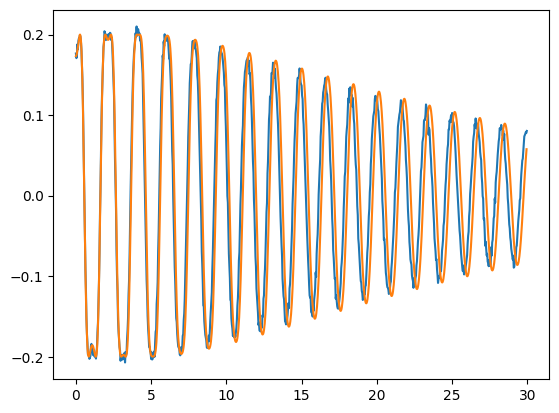

In [ ]:
plt.plot(data[:, 0], data[:, 1])
plt.plot(t_sim, x_sim)